In [134]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
# import cfpy

In [153]:
import utils.common
import utils.conduits
import utils.geos
importlib.reload(utils.common)
importlib.reload(utils.geos)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *



In [146]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [20]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

# Generate Straight Line Multi-conduit Network

In [51]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=20)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [37]:
new_edges['length'] =  np.sqrt((new_edges.x_0 - new_edges.x_1)**2 + (new_edges.y_0 - new_edges.y_1)**2 + (new_edges.z_0 - new_edges.z_1)**2)

In [55]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/edges.csv', index = False)

In [53]:
plot_3D_network(new_nodes, new_edges, node_color='type')

# Generate Network with PyKasso

In [85]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [103]:
settings = 'single_inlet_isotropic'

In [88]:
DEM_path = '../../data/DEM/dem_1m_m.bil'
crs = 'EPSG:32615'
grid = read_DEM_data(DEM_path, x0, x1, y0, y1, dx, dy, crs)

In [95]:
azimuth = 350
dip = np.pi/180/5
slope = np.tan(dip)
azimuth_rad = np.radians(azimuth)
dz_dx = slope * np.cos(azimuth_rad)  # Change in Z per unit X
dz_dy = slope * np.sin(azimuth_rad)  # Change in Z per unit Y
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
grid = z1 - ((nx - x-1)* dx * dz_dx) + ((ny - y-1) * dy * dz_dy)

In [105]:
# top = np.load('../../data/DEM/dem_grid_bear_spring.npy')
model_parameters[settings]['domain']['topography'] = grid.T

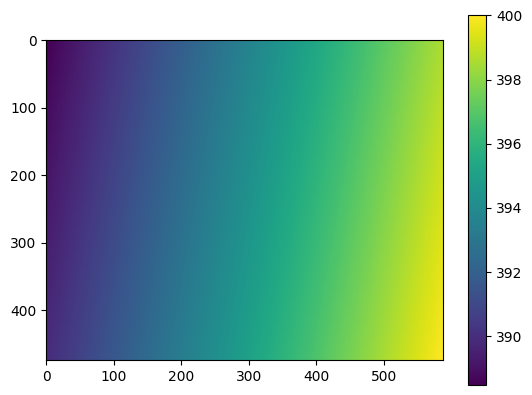

In [98]:
plt.imshow(grid)
plt.colorbar()

In [110]:
for i in range(1):
    app.model.generate(model_parameters[settings])
    # print(app.model.model_parameters['sks']['seed'])


In [164]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)

In [144]:
coords = get_cell_id_from_coords(nodes[nodes.type == 'inlet'].x, nodes[nodes.type=='inlet'].y, x0, y1, dy, dx)

In [153]:
coords = app.project.grid.get_indices(nodes[nodes.type == 'inlet'][['x', 'y']])

<Axes: xlabel='x', ylabel='y'>

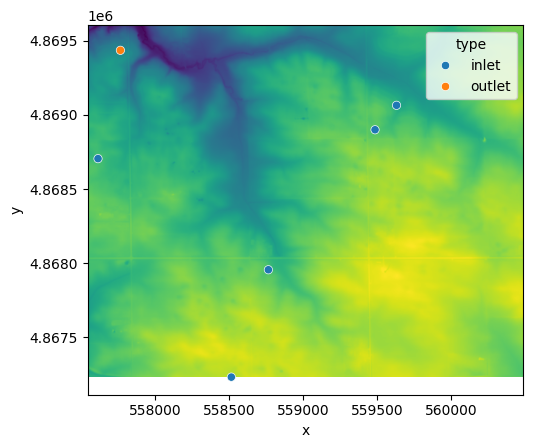

In [150]:
plt.imshow(grid, extent = (x0, x1, y0, y1))
sns.scatterplot(nodes[(nodes.type =='inlet') |(nodes.type =='outlet') ], x = 'x', y = 'y', hue = 'type')

In [29]:
simple_nodes, simple_edges = reduce_edge_density(nodes, edges, 1)

In [32]:
simple_nodes.to_csv("../steady_state/conduit_geometry_test/networks/single_conduit_vert_tort/nodes.csv", index = False)
simple_edges.to_csv("../steady_state/conduit_geometry_test/networks/single_conduit_vert_tort/edges.csv", index = False)

In [34]:
((simple_edges.x_0-simple_edges.x_1)**2 + (simple_edges.y_0-simple_edges.y_1)**2 + (simple_edges.z_0-simple_edges.z_1)**2)**.5

0      21.323338
1      25.993841
2      76.612111
3      60.793009
4      24.858140
         ...    
351    24.858140
352    60.793009
353    76.612111
354    25.993841
355    21.323338
Length: 356, dtype: float64

In [30]:
plot_3D_network(simple_nodes, simple_edges)

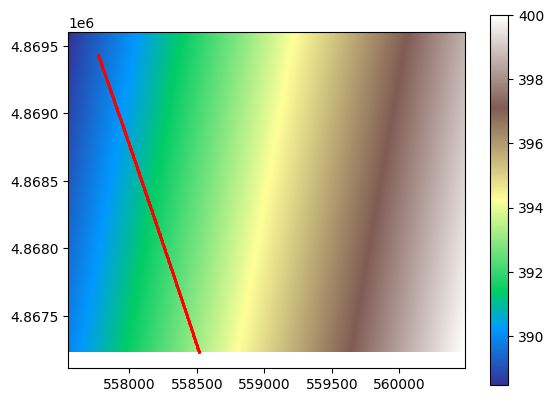

In [113]:
plt.imshow(grid, extent=(x0, x1, y0, y1), origin='upper', cmap='terrain')
plt.colorbar()
plt.scatter(nodes['x'], nodes['y'], c='r', s=1)

In [186]:
plot_3D_network(nodes, edges, node_color='type')

## Changing Slope

In [191]:
dz = 2
nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/sinkhole_spring/nodes.csv")
nodes.loc[nodes.type == 'inlet', 'z'] = dz
nodes.loc[nodes.type=='outlet', 'z'] = 0

In [192]:
edges = pd.DataFrame({'from_id' : [0], 'to_id' : [1]})
nodes, edges = reset_node_ids(nodes, edges)
nodes, edges = densify_edges(nodes, edges, 70)
edges = conduit_lengths(nodes, edges)
edges['dz_dl'] = (edges.z_1 - edges.z_0)/edges.length
plot_3D_network(nodes, edges, node_color = 'type', edge_color = 'dz_dl')

In [193]:
edges

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1,length,dz_dl
0,0,2,558515.000000,4.867230e+06,2.000000,558504.454157,4.867261e+06,1.971831,32.811382,-0.000859
1,2,3,558504.454157,4.867261e+06,1.971831,558493.908313,4.867292e+06,1.943662,32.811382,-0.000859
2,3,4,558493.908313,4.867292e+06,1.943662,558483.362470,4.867323e+06,1.915493,32.811382,-0.000859
3,4,5,558483.362470,4.867323e+06,1.915493,558472.816626,4.867354e+06,1.887324,32.811382,-0.000859
4,5,6,558472.816626,4.867354e+06,1.887324,558462.270783,4.867385e+06,1.859155,32.811382,-0.000859
...,...,...,...,...,...,...,...,...,...,...
66,67,68,557818.974335,4.869281e+06,0.140845,557808.428492,4.869312e+06,0.112676,32.811382,-0.000859
67,68,69,557808.428492,4.869312e+06,0.112676,557797.882648,4.869343e+06,0.084507,32.811382,-0.000859
68,69,70,557797.882648,4.869343e+06,0.084507,557787.336805,4.869374e+06,0.056338,32.811382,-0.000859
69,70,71,557787.336805,4.869374e+06,0.056338,557776.790961,4.869405e+06,0.028169,32.811382,-0.000859


In [195]:
nodes.to_csv("../steady_state/conduit_geometry_test/networks/slope_0008/nodes.csv", index = False)
edges.to_csv("../steady_state/conduit_geometry_test/networks/slope_0008/edges.csv", index = False )

# Closed loop